In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
df = pd.read_csv("/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv")
print("Shape:", df.shape)
df.head()

Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [3]:
import pydicom
import cv2
from tqdm import tqdm

image_id = df["image_id"].unique()
np.random.seed(42)
select_ids=np.random.choice(image_id,2000,replace=False)
output_dir = "/kaggle/working/images3000"
os.makedirs(output_dir, exist_ok=True)


input_dir = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

for img_id in tqdm(select_ids):
    
    dicom_path = os.path.join(input_dir, f"{img_id}.dicom")
    
    # Read DICOM
    ds = pydicom.dcmread(dicom_path)
    
    # Extract pixel data
    image = ds.pixel_array.astype(np.float32)
    
    # Normalize
    image -= image.min()
    if image.max() != 0:
        image /= image.max()
    image *= 255.0
    
    # Convert to uint8
    image = image.astype(np.uint8)
    
    # Save as PNG
    save_path = os.path.join(output_dir, f"{img_id}.png")
    cv2.imwrite(save_path, image)



100%|██████████| 2000/2000 [37:55<00:00,  1.14s/it] 


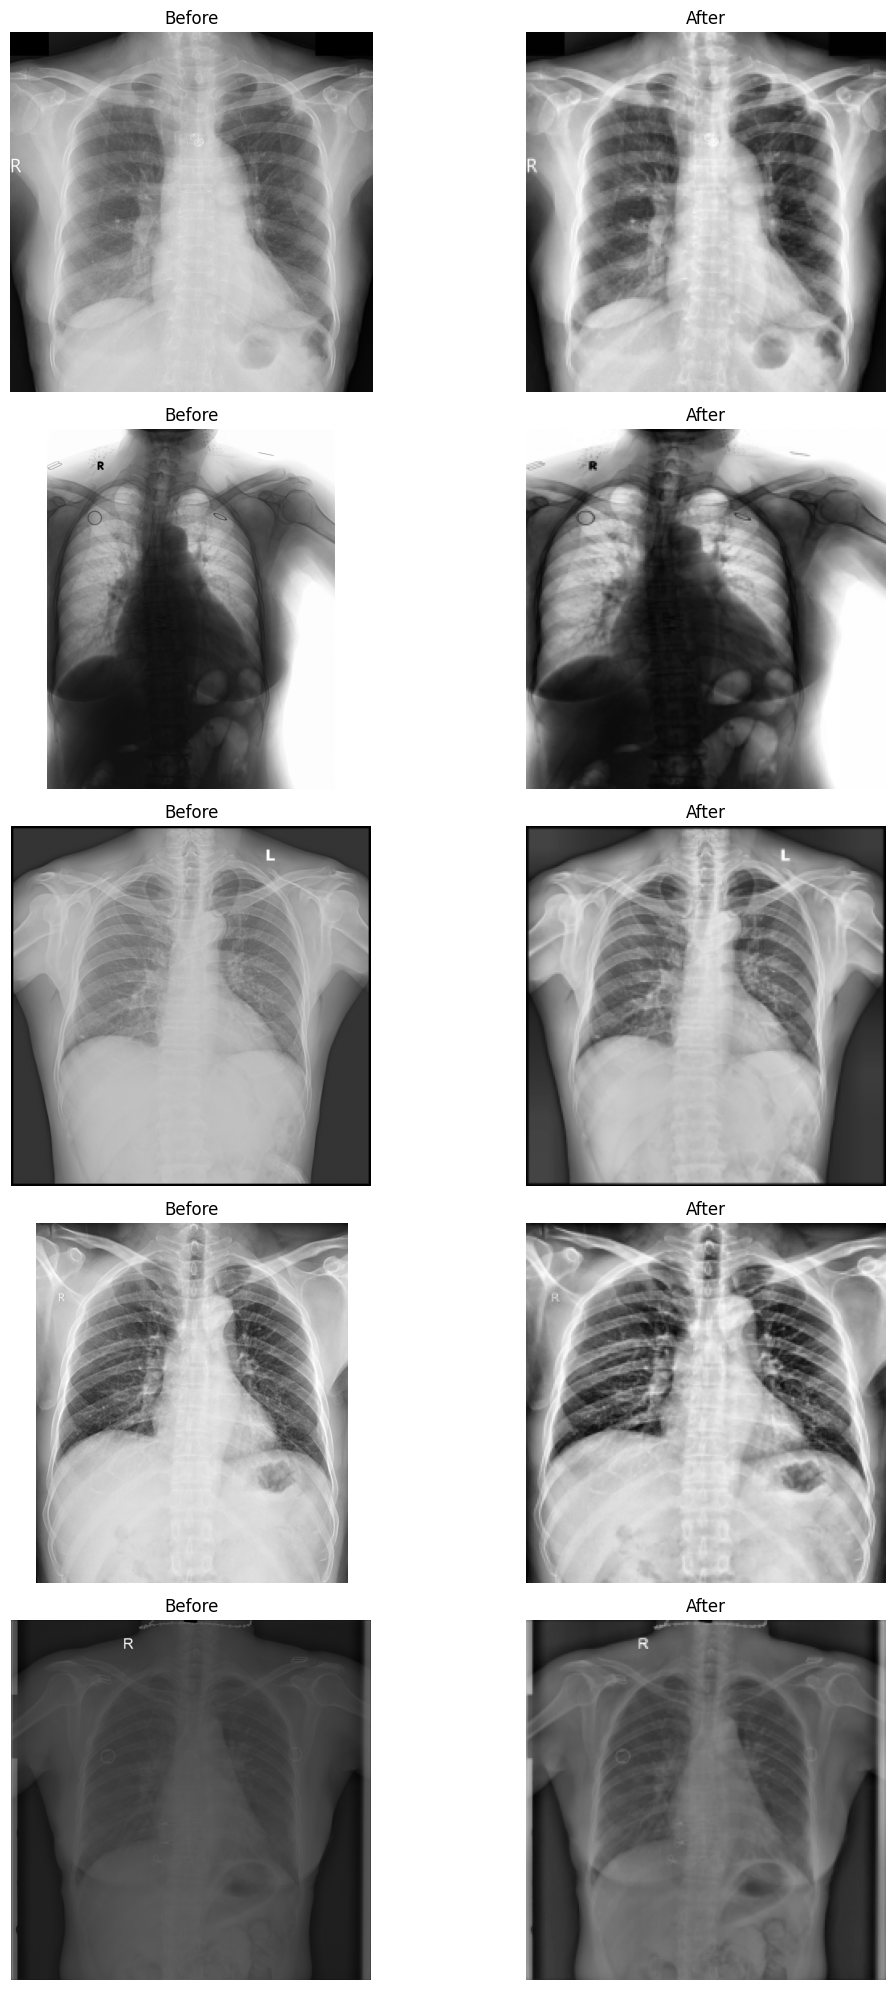

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

image_files = os.listdir(output_dir)

# First image (fixed)
first_image = image_files[0]

# 4 random images (excluding first one to avoid duplicate)
remaining_images = image_files[1:]
random_images = random.sample(remaining_images, 4)

# Combine
selected_images = [first_image] + random_images

plt.figure(figsize=(12,20))

for i, file in enumerate(selected_images):

    sample_path = os.path.join(output_dir, file)

    # -------- BEFORE --------
    original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    
    # -------- PREPROCESS --------
    processed = cv2.resize(original, (512, 512), interpolation=cv2.INTER_AREA)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
    processed = clahe.apply(processed)

    processed = cv2.resize(processed, (224, 224), interpolation=cv2.INTER_AREA)

    processed_norm = processed.astype(np.float32) / 255.0

    # -------- DISPLAY --------
    plt.subplot(5,2,2*i+1)
    plt.imshow(original, cmap="gray")
    plt.title("Before")
    plt.axis("off")

    plt.subplot(5,2,2*i+2)
    plt.imshow(processed_norm, cmap="gray")
    plt.title("After")
    plt.axis("off")

plt.tight_layout()
plt.show()
